# 02 — Modelado y generación de escenarios

## Objetivo

Construir el modelo matemático que permitirá generar escenarios
financieros sintéticos a partir de las características estadísticas
observadas en los datos históricos.

En esta fase todavía no se implementa procesamiento paralelo.

La prioridad es validar primero que el modelo secuencial genere
escenarios correctamente.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:")
print(PROJECT_ROOT)

PROJECT_ROOT:
c:\Users\REYES\OneDrive\Desktop\9noSemestre\programacion paralela\analisis riesgo montecarlo


In [2]:
import numpy as np
import pandas as pd

from src.data.loader import load_csv

In [3]:
PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "sp500_returns.csv"
)

print(PROCESSED_DATA_PATH)

c:\Users\REYES\OneDrive\Desktop\9noSemestre\programacion paralela\analisis riesgo montecarlo\data\processed\sp500_returns.csv


In [4]:
if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        "No existe el dataset procesado. "
        "Ejecuta primero el notebook 01."
    )

print("Dataset procesado encontrado.")

Dataset procesado encontrado.


In [5]:
returns_data = load_csv(
    PROCESSED_DATA_PATH
)

returns_data.head()

,observation_date,SP500,log_return
0,2021-08-24,4486.23,0.001495
1,2021-08-25,4496.19,0.002218
2,2021-08-26,4470.00,-0.005842
3,2021-08-27,4509.37,0.008769
4,2021-08-30,4528.79,0.004297


In [6]:
mean_return = returns_data["log_return"].mean()
volatility = returns_data["log_return"].std()

print(f"Media: {mean_return:.8f}")
print(f"Volatilidad: {volatility:.8f}")

Media: 0.00042932
Volatilidad: 0.01072240


In [7]:
MODEL_MEAN = mean_return
MODEL_STD = volatility

print("Parámetros del modelo:")
print(f"μ = {MODEL_MEAN:.8f}")
print(f"σ = {MODEL_STD:.8f}")

Parámetros del modelo:
μ = 0.00042932
σ = 0.01072240


In [8]:
RANDOM_SEED = 42

rng = np.random.default_rng(
    RANDOM_SEED
)

print(
    f"Generador aleatorio inicializado "
    f"con seed={RANDOM_SEED}"
)

Generador aleatorio inicializado con seed=42


In [9]:
HORIZON_DAYS = 252

synthetic_returns = rng.normal(
    loc=MODEL_MEAN,
    scale=MODEL_STD,
    size=HORIZON_DAYS,
)

print(
    "Número de rendimientos generados:",
    len(synthetic_returns),
)

Número de rendimientos generados: 252


In [10]:
synthetic_returns[:10]

array([ 0.00369662, -0.01072181,  0.00847596,  0.01051444, -0.02049047,
       -0.01353317,  0.00180008, -0.00296156,  0.00024917, -0.00871736])

In [11]:
print(
    f"Media simulada: "
    f"{synthetic_returns.mean():.8f}"
)

print(
    f"Volatilidad simulada: "
    f"{synthetic_returns.std():.8f}"
)

Media simulada: -0.00008932
Volatilidad simulada: 0.01003362


In [12]:
INITIAL_PRICE = 100.0

print(
    f"Precio inicial: {INITIAL_PRICE:.2f}"
)

Precio inicial: 100.00


In [13]:
price_path = (
    INITIAL_PRICE
    * np.exp(
        np.cumsum(synthetic_returns)
    )
)

price_path[:10]

array([100.37034613,  99.29994298, 100.14518256, 101.20370781,
        99.15109778,  97.81830743,  97.99454651,  97.70475907,
        97.72910737,  96.88086999])

In [14]:
price_path = np.insert(
    price_path,
    0,
    INITIAL_PRICE,
)

print(
    "Número de puntos:",
    len(price_path),
)

Número de puntos: 253


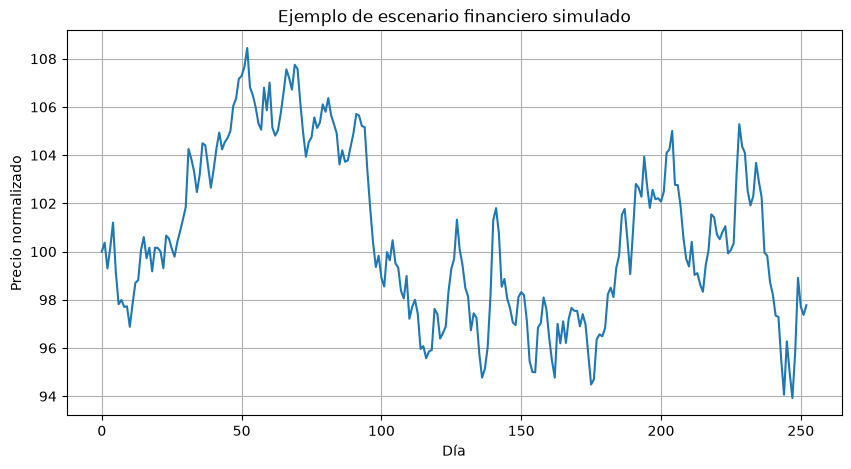

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(price_path)

plt.title(
    "Ejemplo de escenario financiero simulado"
)

plt.xlabel("Día")
plt.ylabel("Precio normalizado")

plt.grid(True)

plt.show()

In [16]:
N_SCENARIOS = 1_000

scenario_returns = rng.normal(
    loc=MODEL_MEAN,
    scale=MODEL_STD,
    size=(
        N_SCENARIOS,
        HORIZON_DAYS,
    ),
)

print(
    "Escenarios:",
    N_SCENARIOS,
)

print(
    "Horizonte:",
    HORIZON_DAYS,
)

print(
    "Shape:",
    scenario_returns.shape,
)

Escenarios: 1000
Horizonte: 252
Shape: (1000, 252)


In [17]:
scenario_prices = (
    INITIAL_PRICE
    * np.exp(
        np.cumsum(
            scenario_returns,
            axis=1,
        )
    )
)

print(
    "Shape de precios:",
    scenario_prices.shape,
)

Shape de precios: (1000, 252)


In [18]:
final_prices = scenario_prices[:, -1]

print(
    "Número de precios finales:",
    len(final_prices),
)

print(
    final_prices[:10]
)

Número de precios finales: 1000
[118.40167917  86.3287182  113.23739491 106.67614722 115.53681846
  71.83331049  74.92392291 104.9919219  125.4490614  125.16609183]


In [19]:
final_returns = (
    final_prices - INITIAL_PRICE
) / INITIAL_PRICE

print(
    final_returns[:10]
)

[ 0.18401679 -0.13671282  0.13237395  0.06676147  0.15536818 -0.2816669
 -0.25076077  0.04991922  0.25449061  0.25166092]


In [20]:
print(
    f"Rendimiento medio: "
    f"{final_returns.mean():.6f}"
)

print(
    f"Rendimiento mínimo: "
    f"{final_returns.min():.6f}"
)

print(
    f"Rendimiento máximo: "
    f"{final_returns.max():.6f}"
)

Rendimiento medio: 0.131005
Rendimiento mínimo: -0.297553
Rendimiento máximo: 0.867135


In [21]:
loss_probability = (
    final_returns < 0
).mean()

print(
    f"Escenarios con pérdida: "
    f"{loss_probability:.2%}"
)

Escenarios con pérdida: 25.60%


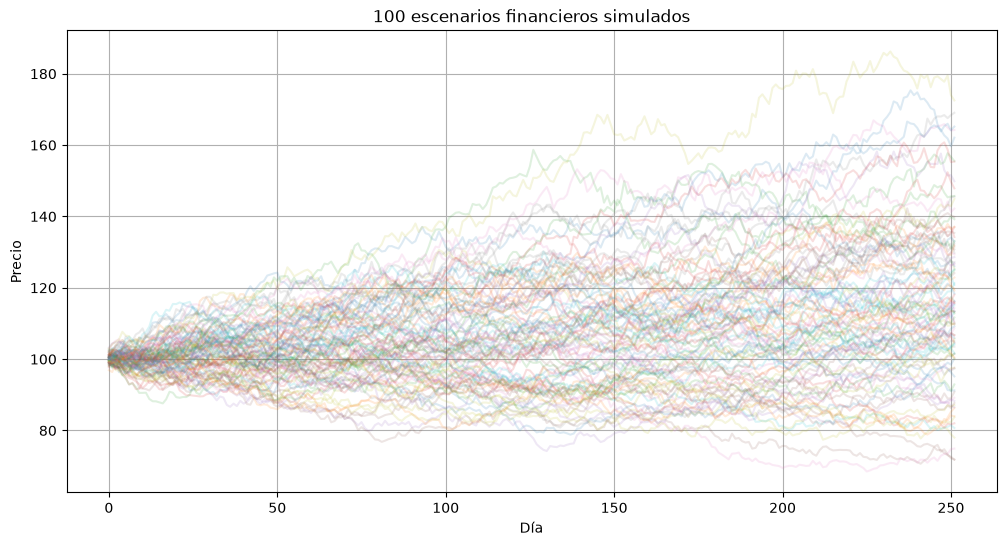

In [22]:
plt.figure(figsize=(12, 6))

for scenario in scenario_prices[:100]:
    plt.plot(
        scenario,
        alpha=0.15,
    )

plt.title(
    "100 escenarios financieros simulados"
)

plt.xlabel("Día")
plt.ylabel("Precio")

plt.grid(True)

plt.show()

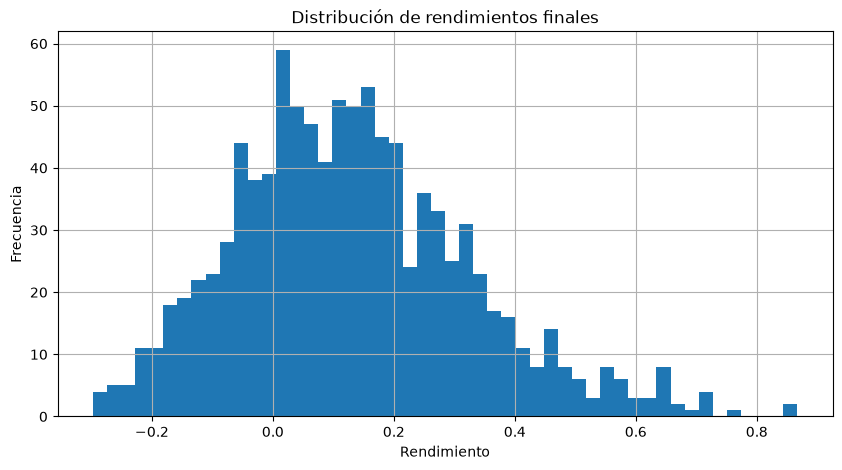

In [23]:
plt.figure(figsize=(10, 5))

plt.hist(
    final_returns,
    bins=50,
)

plt.title(
    "Distribución de rendimientos finales"
)

plt.xlabel("Rendimiento")
plt.ylabel("Frecuencia")

plt.grid(True)

plt.show()

In [24]:
percentiles = np.percentile(
    final_returns,
    [1, 5, 25, 50, 75, 95, 99],
)

percentiles

array([-0.249615  , -0.15903797, -0.00501024,  0.11281391,  0.25127653,
        0.47951328,  0.65746138])

## Interpretación

Los escenarios generados no representan predicciones exactas del
mercado.

Cada escenario representa una posible trayectoria generada a partir
de los parámetros estadísticos estimados a partir de los datos
históricos.

El objetivo es estudiar la distribución de resultados bajo el
modelo utilizado.